<a href="https://colab.research.google.com/github/JKeerti11/PROSOLVER-/blob/main/cyber_attack_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input
from xgboost import XGBClassifier
import shap


In [ ]:
# ✅ NEW CODE: Load the new dataset
df = pd.read_csv("/content/cybersecurity_attacks.csv")  # Update path if needed
print("Dataset shape:", df.shape)


Dataset shape: (21140, 25)


In [ ]:
# Binary Label: Define attacks vs normal
df['label'] = df['Attack Type'].apply(lambda x: 0 if x.lower() == 'normal' else 1)

# Multi-class target
y_attack_type = df['Attack Type']

# Drop non-feature columns
drop_cols = [
    'Timestamp', 'Source IP Address', 'Destination IP Address',
    'Attack Type', 'label'  # include label to keep it only in y
]

X = df.drop(columns=drop_cols)
y_binary = df['label']


In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Encode categorical columns
for col in X.columns:
    if X[col].dtype == 'object' or X[col].apply(lambda v: isinstance(v, str)).any():
        X[col] = X[col].astype(str)
        X[col] = LabelEncoder().fit_transform(X[col])

# Encode targets
y_binary = LabelEncoder().fit_transform(y_binary.astype(str))
y_attack_type = LabelEncoder().fit_transform(y_attack_type.astype(str))

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_bin, y_test_bin, y_train_type, y_test_type = train_test_split(
    X, y_binary, y_attack_type, test_size=0.2, random_state=42, stratify=y_binary
)

# Normalize
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0926 - val_loss: 0.0060
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0042 - val_loss: 0.0015
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011 - val_loss: 5.4774e-04
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.7303e-04 - val_loss: 5.3153e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.3071e-04 - val_loss: 5.2438e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.3004e-04 - val_loss: 5.0618e-04
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1637e-04 - val_loss: 5.2377e-04
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1809e-04 - val_loss: 4.9295e-04
Epoch 9/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.2325e-04 - val_loss: 5.1481e-04
Epoch 10/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.0078e-04 - val_loss: 5.1630e-04
Epoch 11/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9632e-04 - val_loss: 5.5533

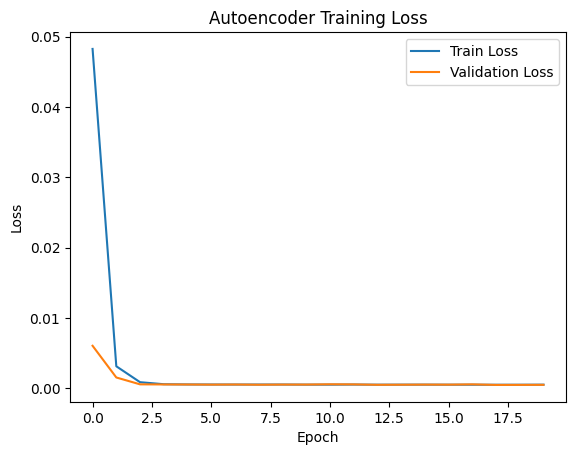

In [ ]:
# Use only normal samples (label = 0) for training
X_train_normal = X_train_scaled[y_train_bin == 0]
input_dim = X_train_normal.shape[1]

# Define encoder and decoder
encoder_layer = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
])
decoder_layer = Sequential([
    Dense(64, activation='relu', input_shape=(32,)),
    Dense(input_dim, activation='sigmoid'),
])

# Autoencoder
inp = Input(shape=(input_dim,))
encoded = encoder_layer(inp)
decoded = decoder_layer(encoded)
autoencoder = Model(inp, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train Autoencoder
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Plot loss curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reconstruction error from autoencoder predictions
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# Define threshold dynamically (mean + 2*std)
threshold = np.mean(mse) + 2 * np.std(mse)
print(f"Dynamic Threshold: {threshold:.4f}")

# Detect anomalies
anomaly_labels = (mse > threshold).astype(int)


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Dynamic Threshold: 0.0009


In [ ]:
# Reconstruction on test data
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# Threshold
threshold = np.percentile(mse, 15)
print("Anomaly Detection Threshold:", threshold)

# Predictions (1 = anomaly, 0 = normal)
autoencoder_preds = (mse > threshold).astype(int)



250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Anomaly Detection Threshold: 0.0002869410915613462


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 946us/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:04:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Attack Type Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.34      0.34      2738
           1       0.33      0.33      0.33      2611
           2       0.32      0.32      0.32      2651

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



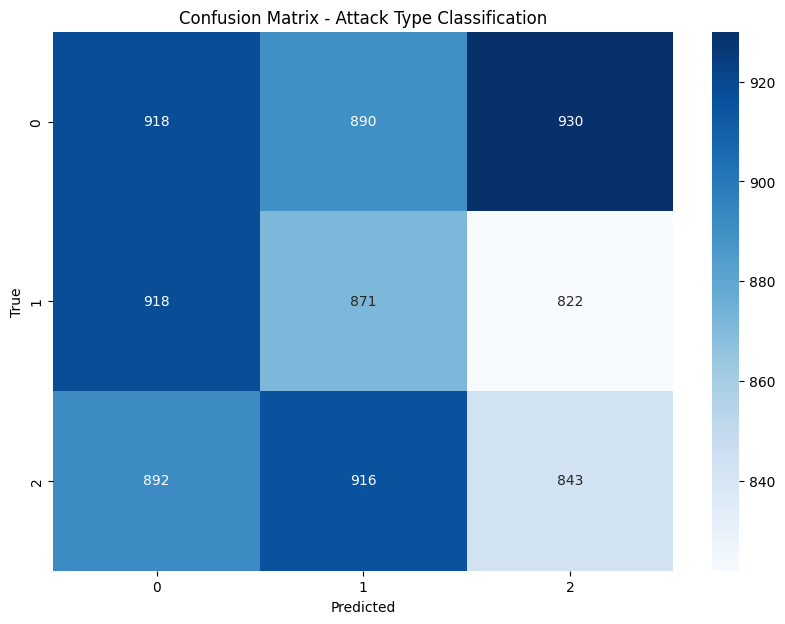

In [ ]:
# Extract latent features
X_train_latent = encoder_layer.predict(X_train_scaled)
X_test_latent = encoder_layer.predict(X_test_scaled)

# Train XGBoost for attack type classification
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train_latent, y_train_type)

# Predict
y_pred = xgb.predict(X_test_latent)

print("Attack Type Classification Report:")
print(classification_report(y_test_type, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test_type, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Attack Type Classification")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


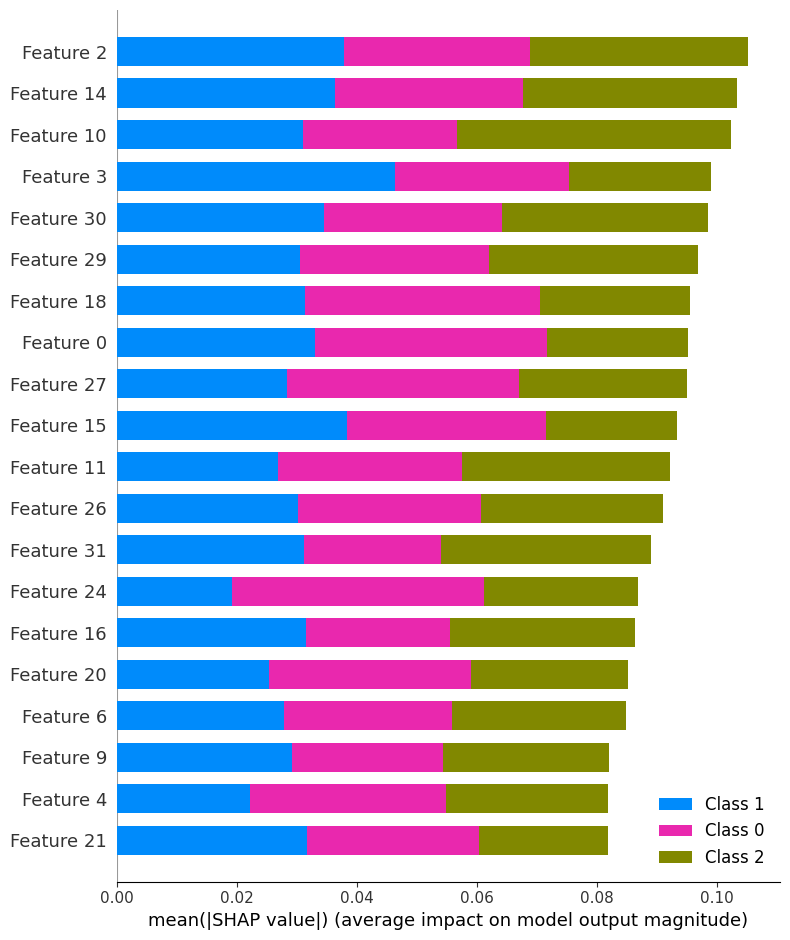

In [ ]:
# SHAP to explain model predictions
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test_latent[:200])
shap.summary_plot(shap_values, X_test_latent[:200])


In [ ]:
# Save Autoencoder and Encoder
autoencoder.save("autoencoder_model.h5")
encoder_layer.save("encoder_model.h5")

# Save XGBoost
import joblib
joblib.dump(xgb, "xgboost_model.pkl")


['xgboost_model.pkl']

In [ ]:
# === Real-Time Simulation ===
import time
import random

print("\n=== Real-Time Intrusion Detection Simulation ===")
for i in range(5):  # Simulate 5 packets
    idx = random.randint(0, X_test_scaled.shape[0] - 1)
    sample = X_test_scaled[idx].reshape(1, -1)

    # Stage 1: Autoencoder Anomaly Detection
    recon = autoencoder.predict(sample)
    mse_score = np.mean(np.power(sample - recon, 2))
    is_anomalous = mse_score > threshold

    print(f"\n[Packet {i+1}] MSE: {mse_score:.5f} --> {'Anomaly' if is_anomalous else 'Normal'}")

    if is_anomalous:
        print("⚠️ Action: Blocked | Quarantine triggered | Alert sent to Admin.")
        # Stage 2: Attack Classification
        latent = encoder_layer.predict(sample)
        attack_type_pred = xgb.predict(latent)[0]
        print(f"🔍 Predicted Attack Type: {attack_type_pred}")
    else:
        print("✅ Action: Packet allowed through.")

    time.sleep(1)



=== Real-Time Intrusion Detection Simulation ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

[Packet 1] MSE: 0.00053 --> Anomaly
⚠️ Action: Blocked | Quarantine triggered | Alert sent to Admin.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
🔍 Predicted Attack Type: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

[Packet 2] MSE: 0.00034 --> Anomaly
⚠️ Action: Blocked | Quarantine triggered | Alert sent to Admin.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
🔍 Predicted Attack Type: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

[Packet 3] MSE: 0.00048 --> Anomaly
⚠️ Action: Blocked | Quarantine triggered | Alert sent to Admin.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
🔍 Predicted Attack Type: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

[Packet 4] MSE: 0.00027 --> Normal
✅ Action: Packet allowed through.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

[Packet 5] MSE: 0.00060 --> Anomaly
⚠️ Action: Blocked | Quarantine triggered | Alert sent to Admin.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
🔍 Predicted Attack Type: 0


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step
NaNs in MSE after cleanup: 0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


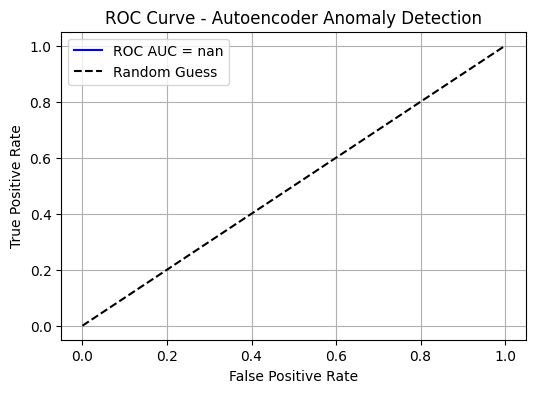

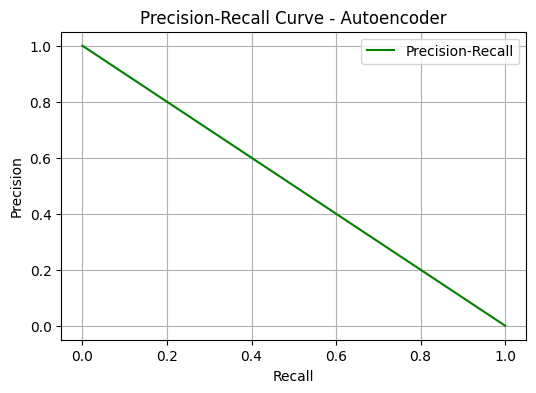

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# === Step 1: Predict reconstruction on test set ===
reconstructions = autoencoder.predict(X_test_scaled)

# === Step 2: Calculate Mean Squared Error ===
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# === Step 3: Clean any NaNs from mse ===
mse = np.nan_to_num(mse)
print("NaNs in MSE after cleanup:", np.isnan(mse).sum())  # Should be 0

# === Step 4: Compute ROC and PR Curves ===
fpr, tpr, _ = roc_curve(y_test_bin, mse)
precision, recall, _ = precision_recall_curve(y_test_bin, mse)
roc_auc = auc(fpr, tpr)

# === Step 5: Plot ROC Curve ===
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve - Autoencoder Anomaly Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# === Step 6: Plot Precision-Recall Curve ===
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label="Precision-Recall", color='green')
plt.title("Precision-Recall Curve - Autoencoder")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("Any NaNs in original data:", df.isnull().sum().sum())



Any NaNs in original data: 99929


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

# STEP 1: Compute reconstruction error from Autoencoder
X_train_recon = autoencoder.predict(X_train_scaled)
X_test_recon = autoencoder.predict(X_test_scaled)

train_error = np.mean(np.square(X_train_scaled - X_train_recon), axis=1)
test_error = np.mean(np.square(X_test_scaled - X_test_recon), axis=1)

# STEP 2: Add reconstruction error as new feature
X_train_df = pd.DataFrame(X_train_scaled, columns=[f'feat_{i}' for i in range(X_train_scaled.shape[1])])
X_test_df = pd.DataFrame(X_test_scaled, columns=[f'feat_{i}' for i in range(X_test_scaled.shape[1])])
X_train_df['recon_error'] = train_error
X_test_df['recon_error'] = test_error

# Explicitly cast data types
X_train_df = X_train_df.astype(np.float32)
X_test_df = X_test_df.astype(np.float32)

# STEP 3: Ensure target labels are integers (0 or 1)
y_train_bin = y_train_bin.astype(np.int32)
y_test_bin = y_test_bin.astype(np.int32)


# STEP 4: Train XGBoost classifier
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    base_score=0.5 # Explicitly set base_score
)
xgb.fit(X_train_df, y_train_bin)

# STEP 5: Predict and Evaluate
y_pred = xgb.predict(X_test_df)

print("Confusion Matrix:\n", confusion_matrix(y_test_bin, y_pred))
print("\nClassification Report:\n", classification_report(y_test_bin, y_pred))

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Confusion Matrix:
 [[8000]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
